<center> <img src = https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/hh%20label.jpg alt="drawing" style="width:400px;">

# <center> Проект: Анализ резюме из HeadHunter
   

<br><br><br><br><br>
**Импорт необходимых модулей.**
**Настройка несколько более удобной, корректной печати DataFrame.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

import builtins
from tabulate import tabulate

# 1) Сохраняем оригинальный print только один раз
if not hasattr(builtins, "_smartprint_original"):
    builtins._smartprint_original = builtins.print

def _tabulate_df(df: pd.DataFrame, tablefmt="psql", showindex=False):
    return tabulate(df, headers="keys", tablefmt=tablefmt, showindex=showindex)

def _tabulate_series(s: pd.Series, tablefmt="psql", showindex=True, name_col="value"):
    df = s.to_frame(name=s.name or name_col)
    return tabulate(df, headers="keys", tablefmt=tablefmt, showindex=showindex)

def smart_print(*args, **kwargs):
    tablefmt = kwargs.pop("tablefmt", "psql")
    showindex = kwargs.pop("showindex", False)
    series_showindex = kwargs.pop("series_showindex", True)

    new_args = []
    for a in args:
        if isinstance(a, pd.DataFrame):
            new_args.append(_tabulate_df(a, tablefmt=tablefmt, showindex=showindex))
        elif isinstance(a, pd.Series):
            new_args.append(_tabulate_series(a, tablefmt=tablefmt, showindex=series_showindex))
        else:
            new_args.append(a)

    # 2) Всегда печатаем через сохранённый оригинал
    return builtins._smartprint_original(*new_args, **kwargs)

# 3) Подменяем print
builtins.print = smart_print

<br><br><br><br><br>
# Исследование структуры данных

<br><br>
**Задание 1**

**Прочитайте данные с помощью библиотеки Pandas.**

**Совет: перед чтением обратите внимание на разделитель внутри файла.**

In [2]:
hh_path = Path("/Users/aleksandrkozlov/Desktop/SF/Блок 1, модуль 10/1 - hh/GH/Data/hh.csv")
hh_data = pd.read_csv(hh_path, sep=';')

<br><br>
**Задание 2**

**Выведите несколько первых (последних) строк таблицы, чтобы убедиться в том, что ваши данные не повреждены.**

**Ознакомьтесь с признаками и их структурой.**

In [3]:
print('Первые 10 строк:\n', hh_data.head(10))
print('\n\nПоследние 10 строк:\n', hh_data.tail(10))

Первые 10 строк:
 +----------------------------------------------+-------------+--------------------------------------------------------------------------------------------+------------------------------------------------------------------------------------+---------------------------------------------------------+------------------------------------------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

<br><br>
**Задание 3**

**Выведите основную информацию о числе непустых значений в столбцах и их типах в таблице.**

In [4]:
print(hh_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Пол, возраст                     44744 non-null  object
 1   ЗП                               44744 non-null  object
 2   Ищет работу на должность:        44744 non-null  object
 3   Город, переезд, командировки     44744 non-null  object
 4   Занятость                        44744 non-null  object
 5   График                           44744 non-null  object
 6   Опыт работы                      44576 non-null  object
 7   Последнее/нынешнее место работы  44743 non-null  object
 8   Последняя/нынешняя должность     44742 non-null  object
 9   Образование и ВУЗ                44744 non-null  object
 10  Обновление резюме                44744 non-null  object
 11  Авто                             44744 non-null  object
dtypes: object(12)
memory usage: 4.1+

<br><br>
**Задание 4**

**Обратите внимание на информацию о числе непустых значений.**

In [5]:
hh_cols_null_percent = hh_data.isnull().mean() * 100
hh_with_null = hh_cols_null_percent[hh_cols_null_percent>0].sort_values(ascending=False)
print('Признаки с наличие пропусков:\n', hh_with_null)

Признаки с наличие пропусков:
 +---------------------------------+------------+
|                                 |      value |
|---------------------------------+------------|
| Опыт работы                     | 0.375469   |
| Последняя/нынешняя должность    | 0.00446987 |
| Последнее/нынешнее место работы | 0.00223494 |
+---------------------------------+------------+


<br><br>
**Задание 5**

**Выведите основную статистическую информацию о столбцах.**


In [6]:
print('Количество уникальных записей по столбцу "Опыт работы": ', hh_data['Опыт работы'].nunique())
print('\n\nСамая распространенная должность: ', hh_data['Ищет работу на должность:'].mode().iloc[0])

Количество уникальных записей по столбцу "Опыт работы":  44413


Самая распространенная должность:  Системный администратор


<br><br><br><br><br>
# Преобразование данных

<br><br>
**Задание 1**

**Обработка столбца 'Образование и ВУЗ' - создание столбца 'Образование'.**

**Сколько соискателей имеет средний уровень образования (школьное образование)?**


In [7]:
# приводим столбец 'Образование и ВУЗ' к новому столбцу 'Образование'
hh_data['Образование'] = hh_data['Образование и ВУЗ'].apply(lambda x: (x.split(' образование')[0]).lower())

# удаляем столбец 'Образование и ВУЗ'
hh_data = hh_data.drop(columns=['Образование и ВУЗ'])

print('Количество соискателей со средним уровнем образования: ', hh_data[hh_data['Образование'] == 'среднее']['Образование'].count())





Количество соискателей со средним уровнем образования:  559


<br><br>
**Задание 2**

**Обработка столбца 'Пол, возраст' - создание отдельных столбцов 'Пол' и 'Возраст'.**

**Сколько процентов женских резюме представлено в наших данных? Ответ округлите до сотых.**

**Чему равен средний возраст соискателей? Ответ округлите до десятых.**


In [8]:
# приводим столбец 'Пол, возраст' к новому столбцу 'Пол'
hh_data['Пол'] = hh_data['Пол, возраст'].apply(lambda x: 'М' if (x.split(',')[0]).lower().strip() == 'мужчина' else 'Ж')

# приводим столбец 'Пол, возраст' к новому столбцу 'Возраст'
hh_data['Возраст'] = hh_data['Пол, возраст'].apply(lambda x: int(x.split(',')[1].strip().split(' ')[0]))

# удаляем столбец 'Пол, возраст'
hh_data = hh_data.drop(columns=['Пол, возраст'])

print('Процент женских резюме:\n', round((hh_data['Пол'].value_counts(normalize=True)*100),2))
print('\n\nСредний возраст соискателей: ', round((hh_data['Возраст'].mean()),1))

Процент женских резюме:
 +-------+--------------+
| Пол   |   proportion |
|-------+--------------|
| М     |        80.93 |
| Ж     |        19.07 |
+-------+--------------+


Средний возраст соискателей:  32.2


<br><br>
**Задание 3**

**Обработка столбца 'Опыт работы' - создание столбца 'Опыт работы (месяц)'.**

**Чему равен медианный опыт работы (в месяцах) в нашей таблице?**

In [9]:
# создаем временный Series draft_stage_data - данные об обыте работе в формате списка элементов, либо же nan по условию задачи
draft_stage_data = hh_data['Опыт работы'].apply(lambda x: np.nan if (pd.isna(x) or x == 'Не указано') else x.split('  ')[0].split('Опыт работы ')[1].split(' '))

# создаем столбец 'Опыт работы (месяц)' - ориентируемся на количество элементов в списке ... если 4 - складываем года + месяцы, если 2 - проверяем месяц ли это, или год (соответственно, при необходимости, умножаем на 12)
hh_data['Опыт работы (месяц)'] = draft_stage_data.apply(lambda x: np.nan if isinstance(x, float) else ((int(x[0])*12)+(int(x[2]))) if len(x) == 4 else (int(x[0]) if 'месяц' in x[1] else int(x[0])*12))
# удаляем столбец 'Опыт работы'
hh_data = hh_data.drop(columns=['Опыт работы'])

print('Медианный опыт работы (в месяцах): ', hh_data['Опыт работы (месяц)'].median())

Медианный опыт работы (в месяцах):  100.0


<br><br>
**Задание 4**

**Обработка столбца 'Город, переезд, командировки' - создание отдельных столбцов 'Город', 'Готовность к переезду', 'Готовность к командировкам'.**

**Сколько процентов соискателей живут в Санкт-Петербурге? Ответ округлите до целого.**

**Сколько процентов соискателей готовы одновременно и к переездам, и к командировкам? Ответ округлите до целого.**

In [10]:
# справочник городов - миллионников
million_cities = ['Новосибирск', 'Екатеринбург', 'Нижний Новгород', 'Казань', 'Челябинск', 'Омск', 'Самара', 'Ростов-на-Дону', 'Уфа', 'Красноярск', 'Пермь', 'Воронеж', 'Волгоград' ]

# создаем временный Series draft_city_moving_data - данные, разбитые по ',' в формате списка
draft_city_moving_data = hh_data['Город, переезд, командировки'].apply(lambda x: x.split(','))

# создаем столбец 'Город'
hh_data['Город'] = draft_city_moving_data.apply(lambda x: x[0].strip() if x[0].strip() in ['Москва','Санкт-Петербург'] else ('город-миллионник' if x[0].strip() in million_cities else 'другие'))
# создаем столбец 'Готовность к переезду'
hh_data['Готовность к переезду'] = draft_city_moving_data.apply(lambda x: False if 'не готов' in (x[1] if 'перее' in x[1] else x[2]) else True)
# создаем столбец 'Готовность к командировкам'
hh_data['Готовность к командировкам'] = draft_city_moving_data.apply(lambda x: False if 'командир' not in (x[-1]) else (False if 'не готов' in (x[-1]) else True))
# удаляем столбец 'Город, переезд, командировки'
hh_data = hh_data.drop(columns=['Город, переезд, командировки'])

print('Процент соискателей, живущих в Санкт-Петербурге: ', round(((hh_data[hh_data['Город']=='Санкт-Петербург']['Город'].count())/(hh_data.shape[0]/100))))
print('\n\nПроцент соискателей, готовых одновременно и к переездам, и к командировкам: ', round(((hh_data[(hh_data['Готовность к переезду']==True)&(hh_data['Готовность к командировкам']==True)]['Готовность к переезду'].count())/(hh_data.shape[0]/100))))

Процент соискателей, живущих в Санкт-Петербурге:  11


Процент соискателей, готовых одновременно и к переездам, и к командировкам:  32


<br><br>
**Задание 5**

**Обработка столбцов 'Занятость' и 'График'. Создание ряда столбцов, связанных с занятостью, также связанных с графиком работы.**

**Сколько людей ищут проектную работу и волонтерство (в обоих столбцах стоит True)?**

**Сколько людей хотят работать вахтовым методом и с гибким графиком (в обоих столбцах стоит True)?**

In [11]:
# временный Series draft_employment -  разбитая по ', ' колонка 'Занятость'
draft_employment = hh_data['Занятость'].apply(lambda x: x.split(', '))
# employment - список всевозможных значений series draft_employment
employment = draft_employment.explode().dropna().unique()

hh_data['частичная занятость'] = hh_data['Занятость'].apply(lambda x: True if 'частичная занятость' in x else False)
hh_data['проектная работа'] = hh_data['Занятость'].apply(lambda x: True if 'проектная работа' in x else False)
hh_data['полная занятость'] = hh_data['Занятость'].apply(lambda x: True if 'полная занятость' in x else False)
hh_data['стажировка'] = hh_data['Занятость'].apply(lambda x: True if 'стажировка' in x else False)
hh_data['волонтерство'] = hh_data['Занятость'].apply(lambda x: True if 'волонтерство' in x else False)

# временный Series draft_schedule -  разбитая по ', ' колонка 'График'
draft_schedule = hh_data['График'].apply(lambda x: x.split(', '))
# schedule - список всевозможных значений series draft_schedule
schedule = draft_schedule.explode().dropna().unique()

hh_data['гибкий график'] = hh_data['График'].apply(lambda x: True if 'гибкий график' in x else False)
hh_data['полный день'] = hh_data['График'].apply(lambda x: True if 'полный день' in x else False)
hh_data['сменный график'] = hh_data['График'].apply(lambda x: True if 'сменный график' in x else False)
hh_data['вахтовый метод'] = hh_data['График'].apply(lambda x: True if 'вахтовый метод' in x else False)
hh_data['удаленная работа'] = hh_data['График'].apply(lambda x: True if 'удаленная работа' in x else False)

# удаляем столбцы 'Занятость' и 'График'
hh_data = hh_data.drop(columns=['Занятость','График'])

print('Количество людей в поиске проектной работы и волонтерства: ', hh_data[(hh_data['проектная работа']==True)&(hh_data['волонтерство']==True)]['проектная работа'].count())
print('\n\nКоличество людей в поиске вахтового метода работы с гибким графиком: ', hh_data[(hh_data['вахтовый метод']==True)&(hh_data['гибкий график']==True)]['вахтовый метод'].count())

Количество людей в поиске проектной работы и волонтерства:  436


Количество людей в поиске вахтового метода работы с гибким графиком:  2311


<br><br>
**Задание 6**

**Обработка столбца 'ЗП'. Создание столбца 'ЗП (руб)'.**

**Чему равна желаемая медианная заработная плата соискателей в нашей таблице (в рублях)?**

In [12]:
well_path = Path("/Users/aleksandrkozlov/Desktop/SF/Блок 1, модуль 10/1 - hh/GH/Data/ExchangeRates.csv")
well_data = pd.read_csv(well_path, sep=',')

from datetime import datetime

# меняем форматы дат по столбцам 'Обновление резюме' и 'date'
hh_data['Обновление резюме'] = hh_data['Обновление резюме'].apply(lambda x: datetime.strptime(x, '%d.%m.%Y %H:%M').date())
well_data['date'] = well_data['date'].apply(lambda x: datetime.strptime(x, '%d/%m/%y').date())

# правим сам столбец 'ЗП'
# создаем временные столбцы 'ЗП (руб)' и 'Валюта'
hh_data['ЗП (руб)'] = hh_data['ЗП'].apply(lambda x: x.split(' ')[0])
hh_data['Валюта'] = hh_data['ЗП'].apply(lambda x: x.split(' ')[1])

# правим коды валют
hh_data['Валюта'] = hh_data['Валюта'].apply(lambda x: x if x not in ['бел.руб.','грн.','сум','руб.'] else ('BYN' if x == 'бел.руб.' else ('UAH' if x == 'грн.' else ('UZS' if x == 'сум' else ('RUB' if x == 'руб.' else np.nan)))))

# соединяем таблицы
hh_data = hh_data.merge(
    right = well_data
    ,how='left'
    ,left_on = ['Валюта','Обновление резюме']
    ,right_on = ['currency','date']
    ,validate = 'm:1'
)

# готовим данные для корректировки
hh_data['ЗП (руб)'] = hh_data['ЗП (руб)'].apply(lambda x: float(x))
hh_data['close'] = hh_data['close'].apply(lambda x: float(x))
hh_data['proportion'] = hh_data['proportion'].apply(lambda x: float(x))
# корректируем столбец 'ЗП (руб)' с учетом валют по данным
hh_data.loc[hh_data['Валюта']!='RUB', 'ЗП (руб)'] = hh_data['ЗП (руб)']*hh_data['close']/hh_data['proportion']

# удаляем лишние столбцы
hh_data = hh_data.drop(columns=['ЗП','Валюта','currency','per','date','time','close','vol','proportion'])

print('Медианная заработная плата соискателей: ', round((hh_data['ЗП (руб)'].median()/1000)))

Медианная заработная плата соискателей:  59


<br><br><br><br><br>
# Исследование зависимостей в данных

<br><br>
**Задание 1**

**Гистограмма и коробчатая диаграмма по признаку 'Возраст'.**

<br>

**Чему равно модальное значение возраста соискателей?**

**Чему равна мода распределения?**

**Каковы предельные значения признака, в каком примерном интервале находится возраст большинства соискателей?**

**Есть ли аномалии для данного признака? Если есть, то какие значения вы бы причислили к таковым?**

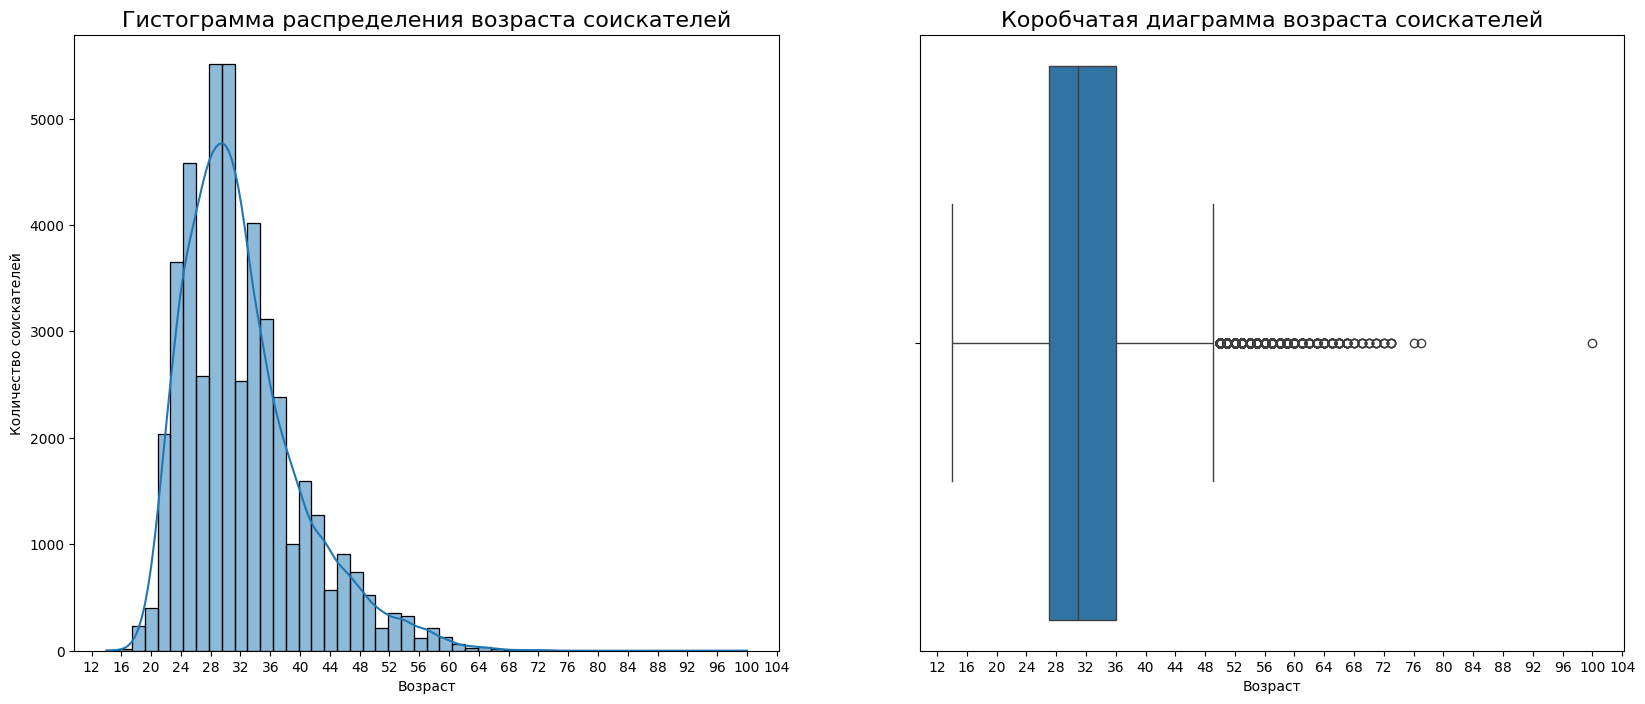

Модальное значение возраста соискателей:  30


In [13]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
sns.histplot(
    data=hh_data['Возраст'],
    bins=50,
    kde=True,
    ax=axes[0]

)
boxplot = sns.boxplot(
    data=hh_data['Возраст'],
    orient='h',
    width=0.9,
    ax=axes[1]
)

axes[0].set_title('Гистограмма распределения возраста соискателей', fontsize=16)
axes[0].set_xlabel('Возраст')
axes[0].set_ylabel('Количество соискателей')
axes[0].xaxis.set_major_locator(plt.MultipleLocator(4))

axes[1].set_title('Коробчатая диаграмма возраста соискателей', fontsize=16)
axes[1].set_xlabel('Возраст')
axes[1].xaxis.set_major_locator(plt.MultipleLocator(4))

plt.show()
print('Модальное значение возраста соискателей: ', hh_data['Возраст'].mode().iloc[0])

$\color{red}{\mathbf{Итог:}}$

Мода распределения возраста соискателей - 30 лет.

Предельные значения соискателей от 14 до 49 лет. Основной возраст соискателей в диапазоне 22 - 38 лет.

Присутствуют аномалии - выбросы. К выбросам можно отнести соискателей в диапазоне от 50 до 75 лет и одного выше 100 лет. Но здесь требуется более детальный анализ.

<br><br><br><br>
**Задание 2**

**Коробчатая диаграмма по признаку 'Опыт работы (месяц)'.**

<br>

**Чему равен максимальный опыт работы (в месяцах)?**

**Чему равна мода распределения?**

**Каковы предельные значения признака, в каком примерном интервале находится опыт работы большинства соискателей?**

**Есть ли аномалии для признака? Если есть, то какие значения вы бы причислили к таковым?**

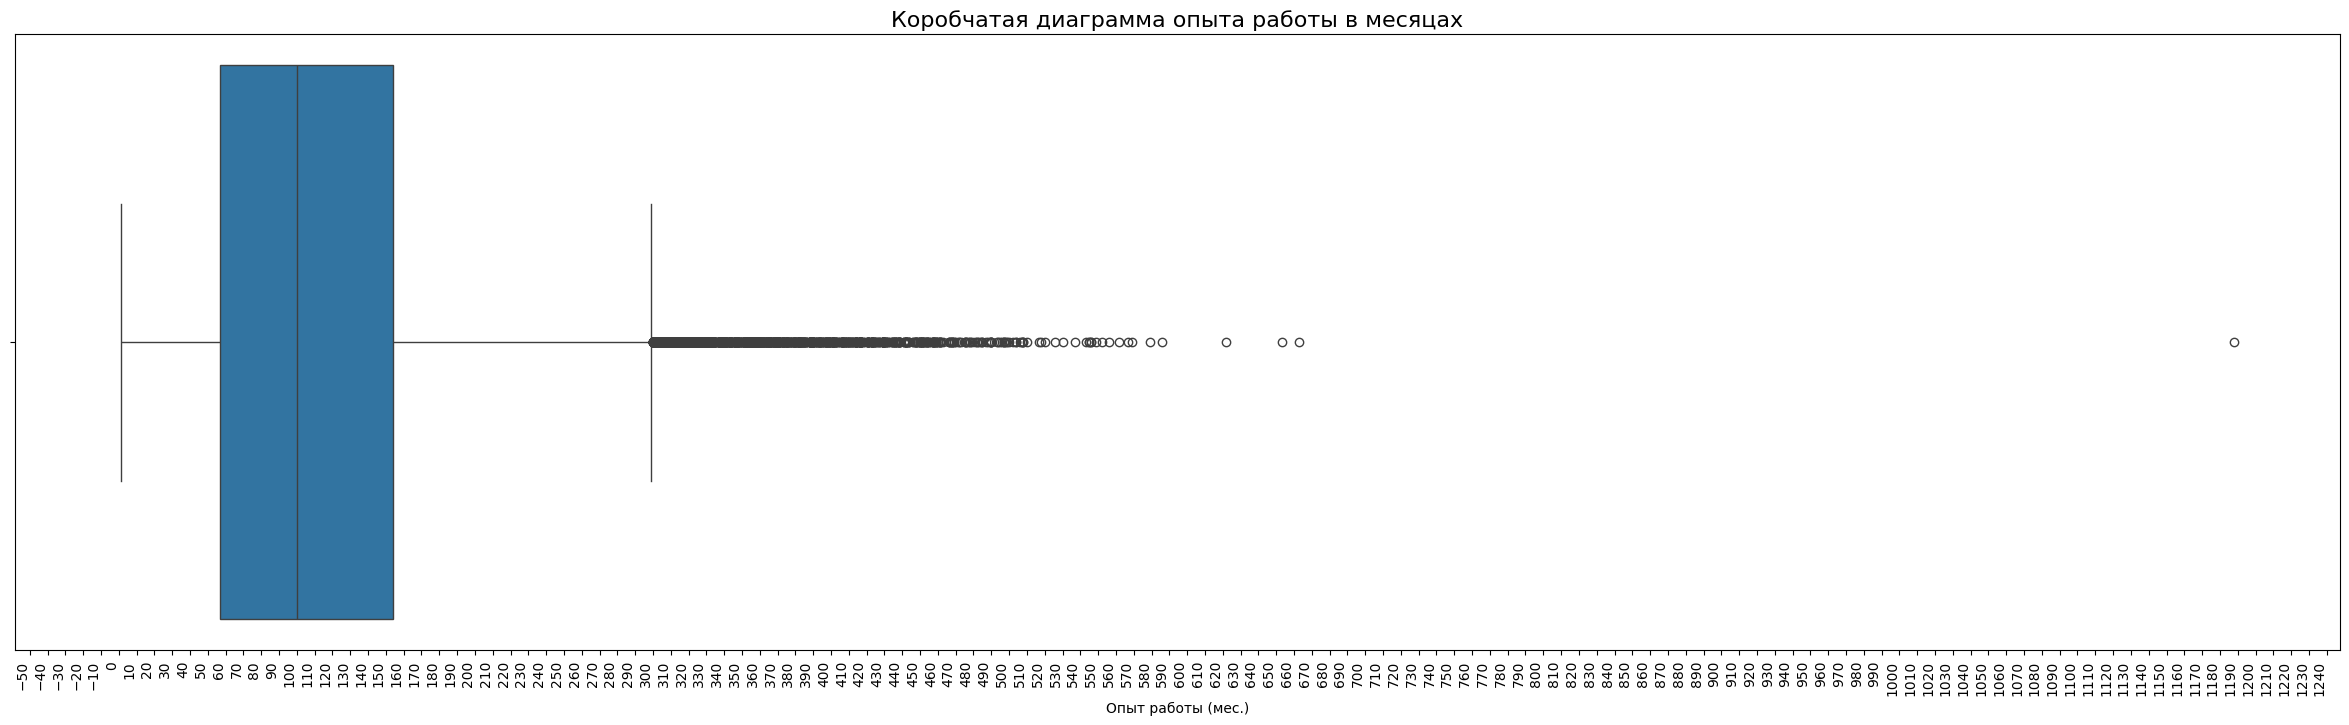

Максимальный опыт работы соискателей (в месяцах):  1188


In [14]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(30, 8))
sns.boxplot(
    data=hh_data['Опыт работы (месяц)'],
    orient='h',
    width=0.9,
)

axes.set_title('Коробчатая диаграмма опыта работы в месяцах', fontsize=16)
axes.set_xlabel('Опыт работы (мес.)')
axes.xaxis.set_major_locator(plt.MultipleLocator(10))
plt.xticks(rotation=90, ha='right')
plt.show()
print('Максимальный опыт работы соискателей (в месяцах): ', round((hh_data['Опыт работы (месяц)'].max())))

$\color{red}{\mathbf{Итог:}}$

Максимальный опыт работы соискателей (в месяцах) - 1188

Мода значения опыта работы соискателей (в месяцах) - 81

Предельные значения соискателей от 0 до 310 месяцев. Основной масса соискателей имеют опыт от 55 до 155 месяцев.

Присутствуют аномалии - выбросы. К выбросам можно отнести соискателей с опытом работы более 310 месяцев и выше, также одного соискателя с опытом 1188 месяцев. Но здесь требуется более детальный анализ.

<br><br><br><br>
**Задание 3**

**Коробчатая диаграмма по признаку 'ЗП (руб)'.**

<br>

**Определите по графику, сколько соискателей требуют заработную плату выше 1 миллиона рублей.**

**Чему равна мода распределения?**

**Каковы предельные значения признака, в каком примерном интервале находится заработная плата большинства соискателей?**

**Есть ли аномалии для признака заработной платы? Если есть, то какие значения вы бы причислили к таковым?**

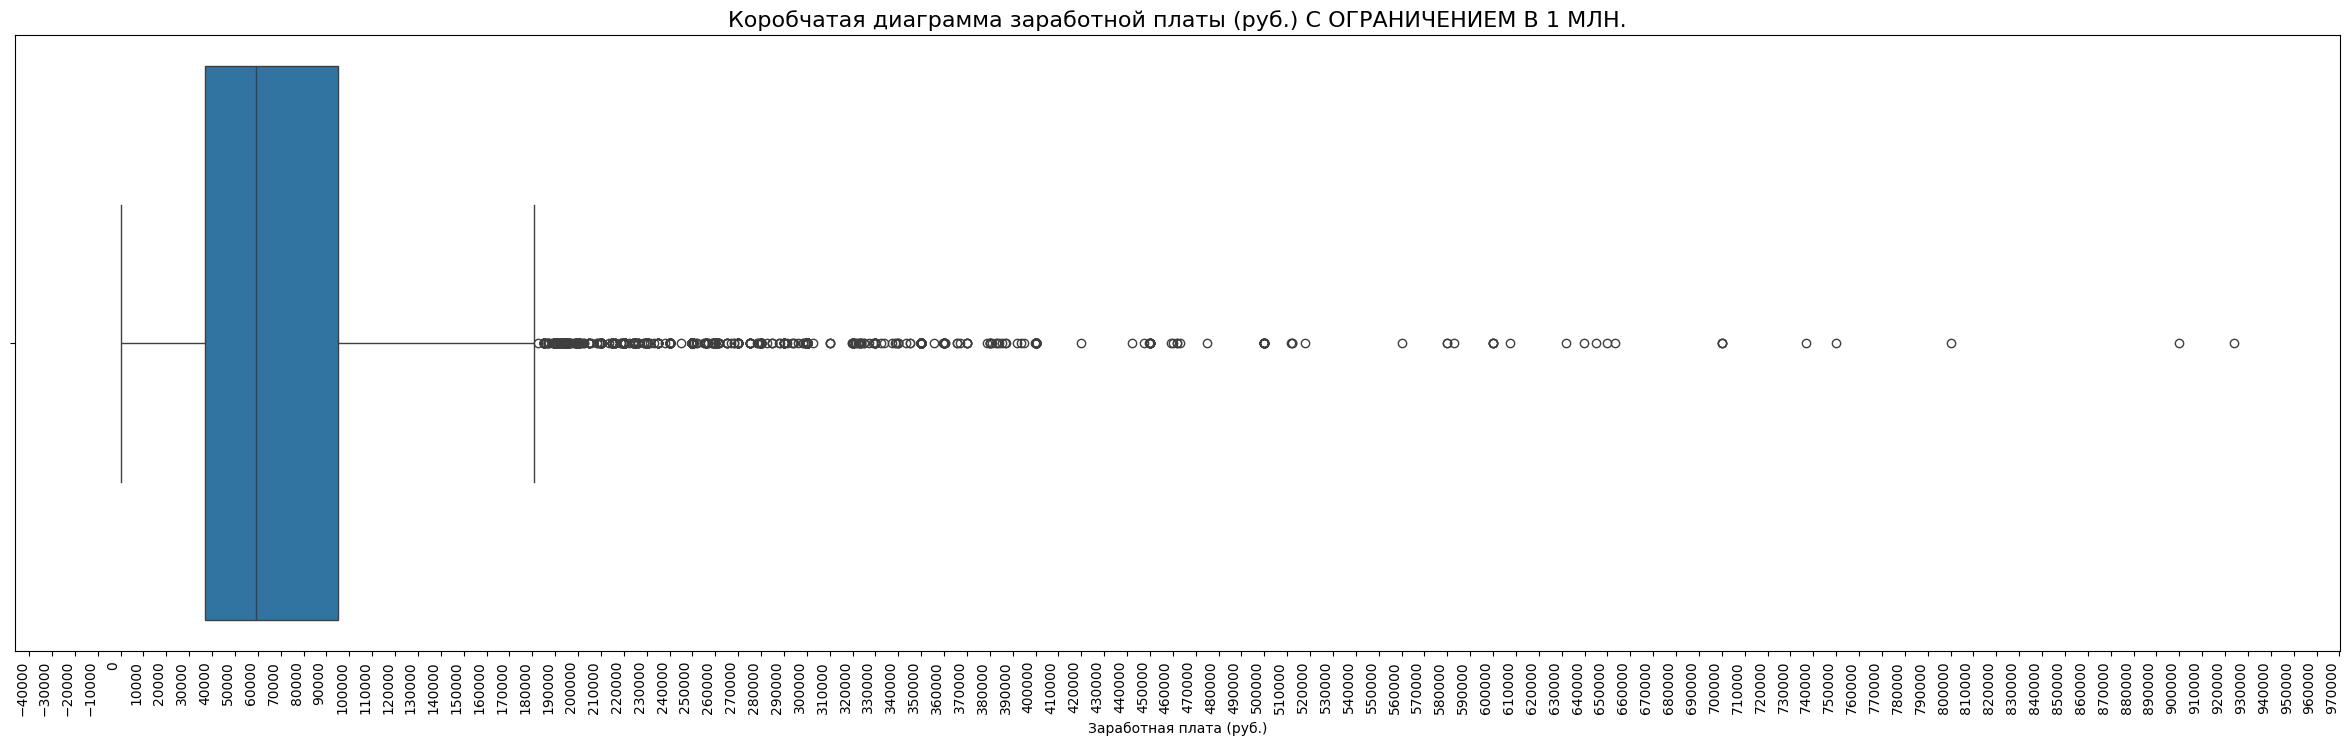

Количество соискателей, требующих заработную плату свыше 1 000 000 руб.:  5


 Мода распределения заработной платы:  50000.0


In [15]:
# для корректной визуализации ограничиваем диаграмму верхней планкой в 1 млн. руб.
zp_data = hh_data[hh_data['ЗП (руб)']<1000000]['ЗП (руб)']

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(30, 8))
sns.boxplot(
    data=zp_data,
    orient='h',
    width=0.9,
)

axes.set_title('Коробчатая диаграмма заработной платы (руб.) С ОГРАНИЧЕНИЕМ В 1 МЛН.', fontsize=16)
axes.set_xlabel('Заработная плата (руб.)')
axes.xaxis.set_major_locator(plt.MultipleLocator(10000))
plt.xticks(rotation=90, ha='right')
plt.show()

print('Количество соискателей, требующих заработную плату свыше 1 000 000 руб.: ', hh_data[hh_data['ЗП (руб)']>1000000]['ЗП (руб)'].count())
print('\n\n Мода распределения заработной платы: ', hh_data['ЗП (руб)'].mode().loc[0])

$\color{red}{\mathbf{Итог:}}$

Количество соискателей, требующих заработную плату свыше 1 000 000 руб. - 5

Мода распределения заработной планы - 50 000 руб.

Предельные значения соискателей по заработной плате примерно от 0 до 180 000 руб. Основной масса соискателей ищут работу с заработной платой в диапазоне примерно от 35 000 до 95 000 руб.

Присутствуют аномалии - выбросы. К выбросам можно отнести соискателей, ищущих работу с заработной платой выше 180 000 руб. Но здесь требуется более детальный анализ.

<br><br><br><br>
**Задание 4**

**Столбчатая диаграмма зависимости в ожидаемой заработной плате от уровня образования. (Данные до 1 млн. руб.)**

<br>

**Какая категория образования оплачивается выше всех по медианному показателю?**

**Для каких уровней образования наблюдаются наибольшие и наименьшие уровни желаемой заработной платы?**

**Как вы считаете, важен ли признак уровня образования при прогнозировании заработной платы?**

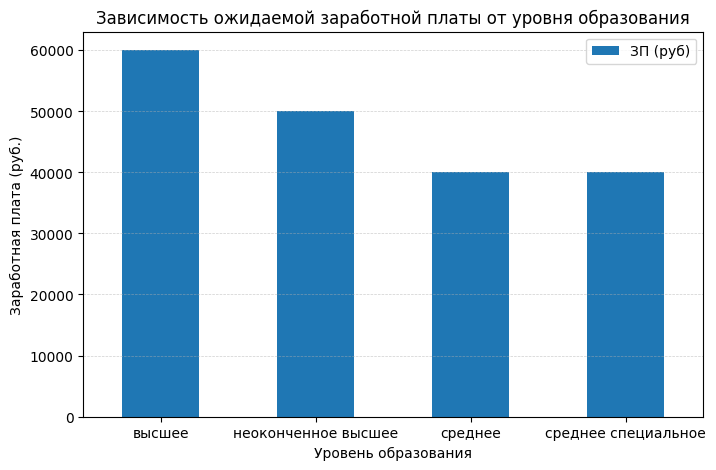

In [16]:
# сделаем отдельную выборку
zp_data = hh_data[hh_data['ЗП (руб)']<1000000]
# также сделаем по ней сводную таблицу
education_zp_data = zp_data.pivot_table(
    index='Образование',
    values='ЗП (руб)',
    aggfunc='median',
    fill_value=0
)

axes = (
    education_zp_data
    .plot(kind='bar', figsize=(8, 5), rot=0)
)

axes.set_title('Зависимость ожидаемой заработной платы от уровня образования')
axes.set_xlabel('Уровень образования')
axes.set_ylabel('Заработная плата (руб.)')
axes.grid(axis='y', linestyle="--", linewidth=0.5, alpha=0.6)
axes.legend(loc='upper right')

plt.show()

$\color{red}{\mathbf{Итог:}}$

Выше всего по медианному показателю оплачивается образование категории 'высшее'.

Наибольший уровень оплаты труда наблюдается для категории образования 'высшее', наименьший для таких категорий как 'среднее специальное' и 'среднее'.

Полагаю, можно сказать, что признак уровня образования является важным при прогнозировании заработной платы.

<br><br><br><br>
**Задание 5**

**Столбчатая диаграмма зависимости в ожидаемой заработной плате от города проживания. (Данные до 1 млн. руб.)**

<br>

**В каком городе (категории городов) зафиксирован наибольший показатель желаемой заработной платы (~924 тысячи рублей)?**

**Как соотносятся медианные уровни желаемой заработной платы и их размах в городах?**

**Как вы считаете, важен ли признак города при прогнозировании заработной платы?**

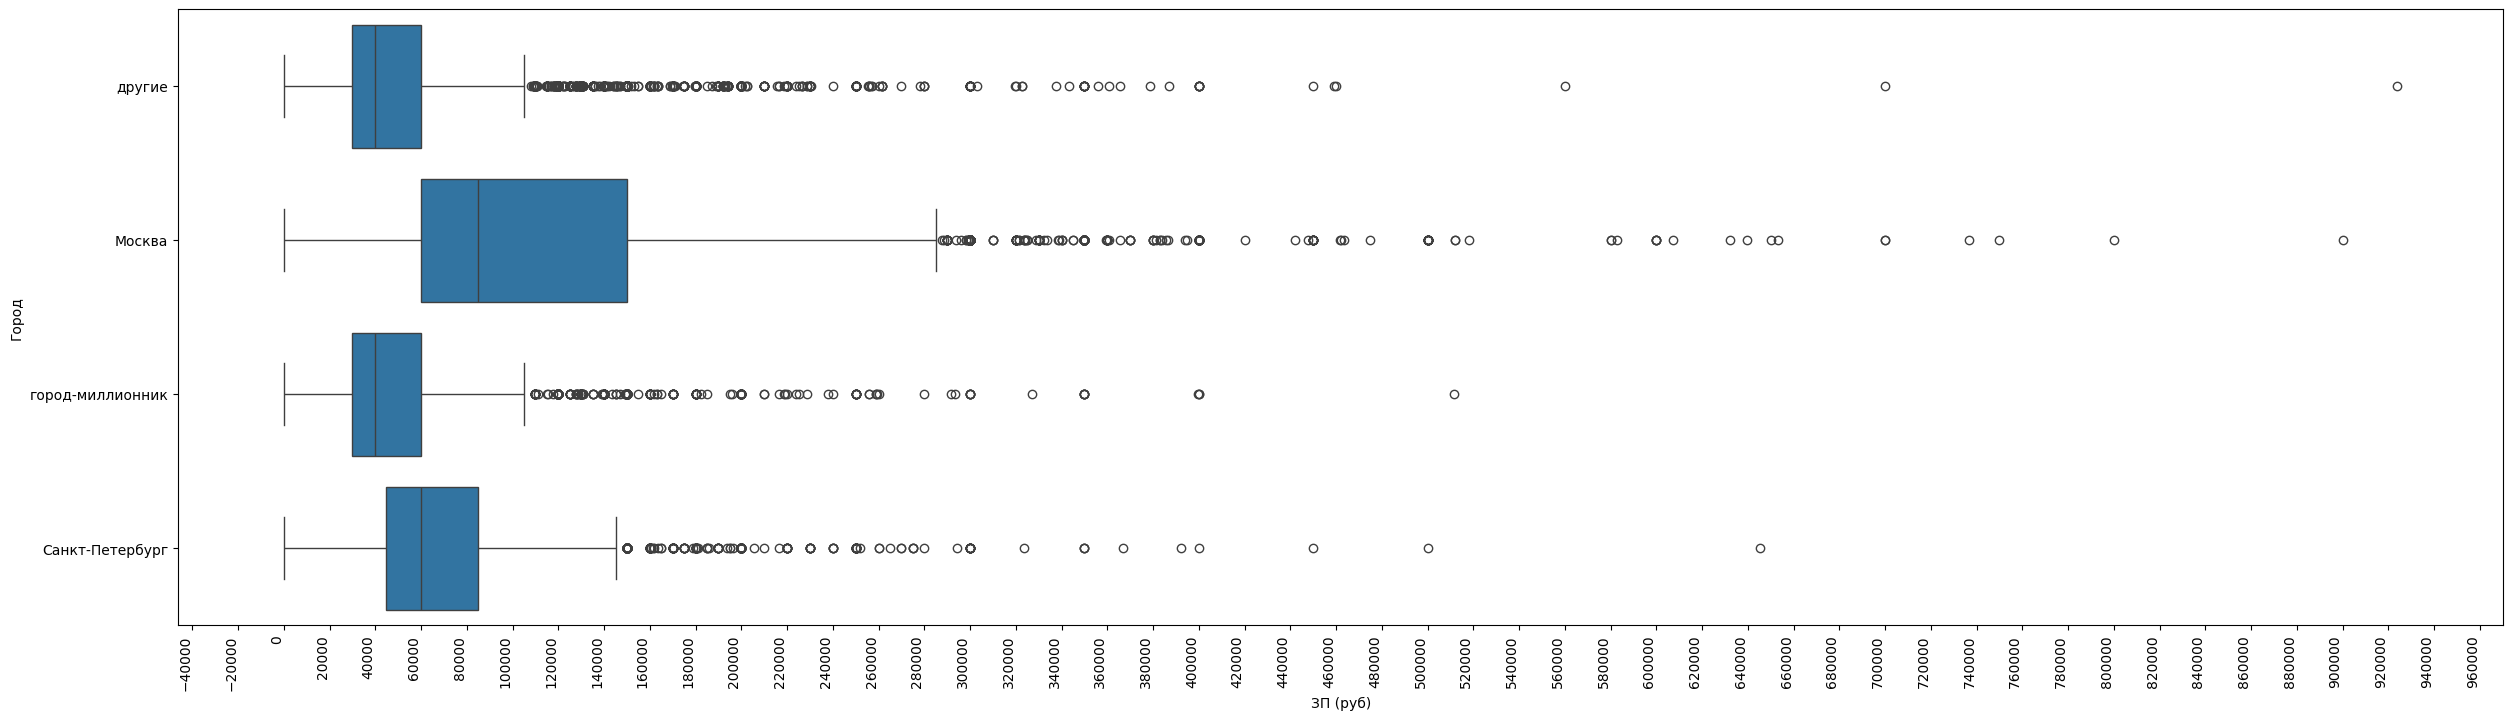

In [17]:
# сделаем отдельную выборку
zp_data = hh_data[hh_data['ЗП (руб)'] < 1_000_000]

plt.figure(figsize=(30, 8))
axes = sns.boxplot(data=zp_data, x='ЗП (руб)', y='Город')
axes.xaxis.set_major_locator(plt.MultipleLocator(20000))
plt.xticks(rotation=90, ha='right')
plt.show()

$\color{red}{\mathbf{Итог:}}$

Наибольший показатель желаемой заработной платы зафиксирован в категории городов 'другие', что, вероятно, можно отвести к выбросам.

Наибольший медианный уровень желаемой заработной платы зафиксирован в Москве, как и размах основного диапазона желаемой заработной платы, как и размах усов.
После Москвы, по уровню медианной желаймой заработной планы, размаху основного диапазона и усов идет Санкт - Петербург.
Далее, значительной разницы между городами - миллионниками и другими, менее крупными городами не выявлено, данные почти одинаковые, за исключением разницы по количеству выбросов.

Полагаю, можно сказать, что такой признак, как город проживания, является более чем важным, при прогнозировании заработной платы.

<br><br><br><br>
**Задание 6**

**Диаграмма, отображающая зависимость медианной желаемой заработной платы от признаков готовности к переезду и готовности к командировкам.**

<br>

**Чему равна желаемая медианная заработная плата соискателей, готовых и к переезду, и к командировкам? Ответ приведите в тысячах, округлив до целого.**

**Проанализируйте график, сравнив уровень заработной платы по категориям.**

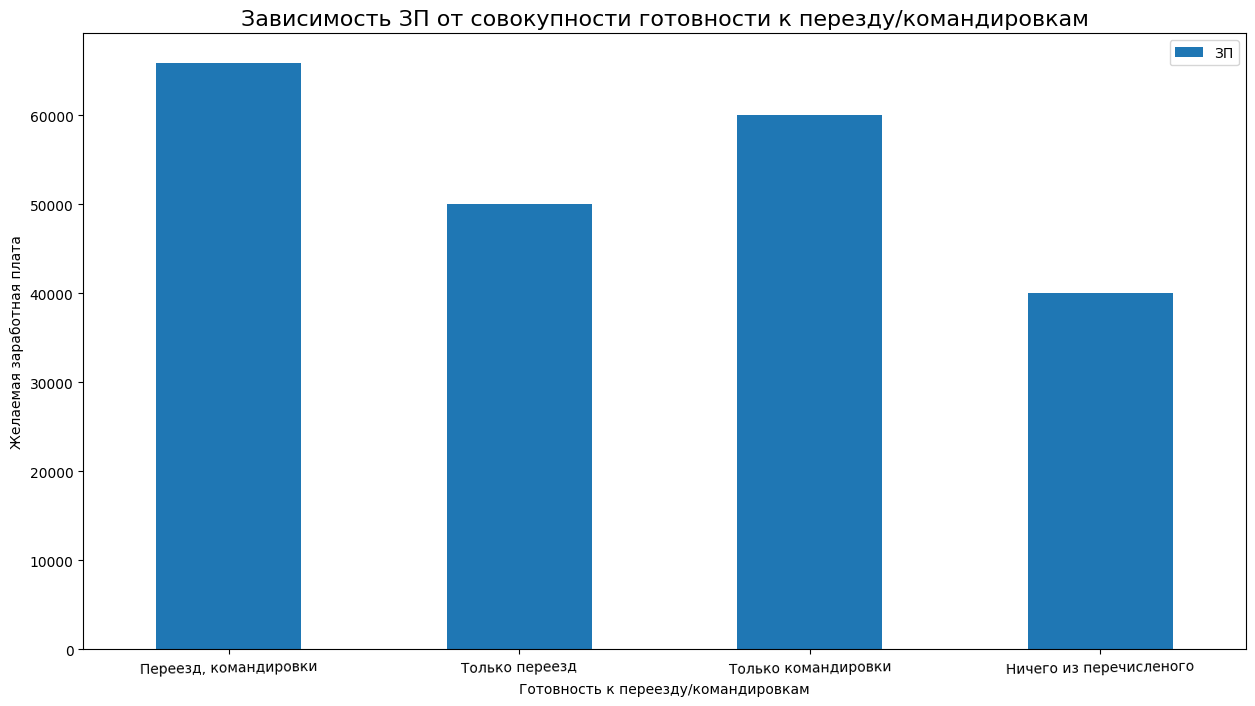

Медианная заработная плата соискателей, готовых как к переездам, так и к командировкам:  66000.0


In [18]:
# сделаем отдельный DataFrame
moving_zp_data = pd.DataFrame({
    'ЗП':[\
        hh_data[(hh_data['Готовность к переезду']==True)&(hh_data['Готовность к командировкам']==True)]['ЗП (руб)'].median()\
        ,hh_data[(hh_data['Готовность к переезду']==True)&(hh_data['Готовность к командировкам']==False)]['ЗП (руб)'].median()\
        ,hh_data[(hh_data['Готовность к переезду']==False)&(hh_data['Готовность к командировкам']==True)]['ЗП (руб)'].median()\
        ,hh_data[(hh_data['Готовность к переезду']==False)&(hh_data['Готовность к командировкам']==False)]['ЗП (руб)'].median()\
        ],
    'Готовность к переезду/командировкам':[\
        'Переезд, командировки'\
        ,'Только переезд'\
        ,'Только командировки'\
        ,'Ничего из перечисленого'\
        ],
}).set_index('Готовность к переезду/командировкам')

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(15, 8))

moving_zp_data.plot(kind='bar', rot=1, ax=axes)
axes.set_title('Зависимость ЗП от совокупности готовности к перезду/командировкам', fontsize=16)
axes.set_xlabel('Готовность к переезду/командировкам')
axes.set_ylabel('Желаемая заработная плата')

plt.show()

print('Медианная заработная плата соискателей, готовых как к переездам, так и к командировкам: ', round((hh_data[(hh_data['Готовность к переезду']==True)&(hh_data['Готовность к командировкам']==True)]['ЗП (руб)'].median()),-3))

$\color{red}{\mathbf{Итог:}}$

Медианная заработная плата соискателей, готовых как к переездам, так и к командировкам - 66 тыс. руб.

Анализируя диаграмму, можно сделать вывод, что медианная ожидаемая заработная плата растет с увеличением мобильности, но готовность к командировкам являются более существенным признаком, влияющим на уровень ожидаемой ЗП. 

<br><br><br><br>
**Задание 7**

**Сводная таблица зависимости медианной желаемой заработной платы от возраста и образования. Тепловая карта на основе построенной сводной таблицы.**

<br>

**Для какой категории образования наблюдается самый быстрый карьерный рост (то есть интенсивность роста заработной платы наибольшая)?**

**Проанализируйте тепловую карту, сравнив показатели внутри групп.**

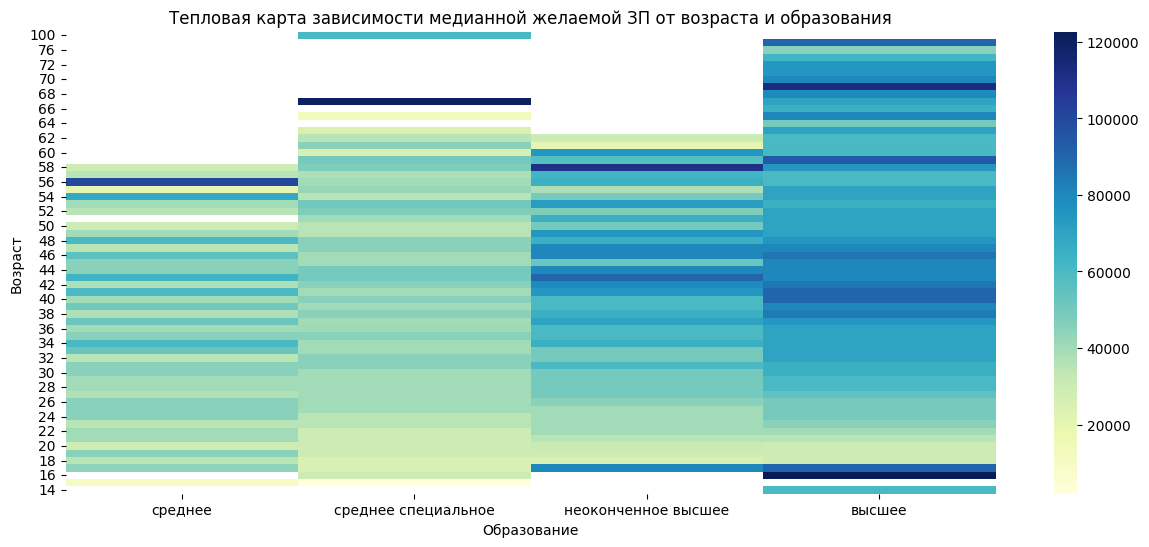

In [19]:

# сделаем сводную таблицу
age_education_zp_data = hh_data.pivot_table(
    index='Возраст',
    columns='Образование',
    values='ЗП (руб)',
    aggfunc='median'
)

age_education_zp_data = age_education_zp_data[['среднее','среднее специальное','неоконченное высшее','высшее']]

plt.figure(figsize=(15, 6))

ax = sns.heatmap(age_education_zp_data, cmap='YlGnBu')
ax.invert_yaxis()
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')

plt.title('Тепловая карта зависимости медианной желаемой ЗП от возраста и образования')
plt.show()

$\color{red}{\mathbf{Итог:}}$

Наиболее быстрый карьерный рост наблюдается для категории образования - 'высшее'. Также видно, что 'потолок' желаемой заработной платы в категории образования 'высшее' также значительно выше.

По графику также видны выбросы в виде некорректно высоких ожиданий по заработной плате для категорий 'неоконченное высшее' и 'высшее' для групп соискателей в возрастном диапазоне 16 - 18 лет.

<br><br><br><br>
**Задание 7**

**Диаграмма рассеяния зависимости опыта работы (в годах) от возраста.**
**Постройте на графике дополнительно прямую, проходящую через точки (0, 0) и (100, 100).**

<br>

**Сколько точек лежат строго выше построенной прямой?**

In [20]:
# возьмем отдельную выборку
experience_age_data = hh_data[['Возраст','Опыт работы (месяц)']].copy()
experience_age_data['Опыт работы'] = experience_age_data['Опыт работы (месяц)'].apply(lambda x: round(((x/12)),2))

fig = px.scatter(
    experience_age_data,
    x='Возраст', y='Опыт работы',
)

fig.update_traces(marker=dict(opacity=0.8, line=dict(width=0.5)))
fig.update_xaxes(range=[0, 100])
fig.update_yaxes(range=[0, 100])
fig.add_shape(type='line',x0=0, y0=0, x1=100, y1=100,line=dict(width=2,color='red'))
fig.show()





# строго выше линии y=x

print('Явных выбросов: ', experience_age_data[experience_age_data['Опыт работы'] > experience_age_data['Возраст']]['Опыт работы'].count())



Явных выбросов:  7


$\color{red}{\mathbf{Итог:}}$

Явных выбросов (взято по результатам запроса) - 7.

Также есть любопытная тенденция сохранения группы соискателей с отсутствующим или явно низким опытом работы и высоким признаком возраста, что может указывать на выбросы.

Также можно попробовать добавить 'линию' и для тех соискателей, чей признак возраста не высок, но при этом высокий признак опыта работы.



<br><br><br><br>
**Дополнительно.**

**Построить два дополнительных графика, диаграммы. Привести выводы.**


In [21]:
# ГРАФИК 1

# возьмем типы трудоустройства
sl = ['полная занятость','полный день','гибкий график','удаленная работа','частичная занятость','сменный график','проектная работа','вахтовый метод','стажировка','волонтерство']
test = pd.DataFrame({
    'Количество соискателей':[\
         hh_data[(hh_data[sl[0]]==True)]['ЗП (руб)'].shape[0]\
        ,hh_data[(hh_data[sl[1]]==True)]['ЗП (руб)'].shape[0]\
        ,hh_data[(hh_data[sl[2]]==True)]['ЗП (руб)'].shape[0]\
        ,hh_data[(hh_data[sl[3]]==True)]['ЗП (руб)'].shape[0]\
        ,hh_data[(hh_data[sl[4]]==True)]['ЗП (руб)'].shape[0]\
        ,hh_data[(hh_data[sl[5]]==True)]['ЗП (руб)'].shape[0]\
        ,hh_data[(hh_data[sl[6]]==True)]['ЗП (руб)'].shape[0]\
        ,hh_data[(hh_data[sl[7]]==True)]['ЗП (руб)'].shape[0]\
        ,hh_data[(hh_data[sl[8]]==True)]['ЗП (руб)'].shape[0]\
        ,hh_data[(hh_data[sl[9]]==True)]['ЗП (руб)'].shape[0]\
        ],
    'Типы трудоустройства':sl
})
fig = px.bar(
    test,
    x='Типы трудоустройства',
    y='Количество соискателей'
)
fig.update_layout(
        legend_title_text='Показатели',
        title='Соотношение соискателей в разрезе разных типов трудоустройства',
        width=2000, height=800,
    )
fig.update_xaxes(
        title='Типы трудоустройства',
        showgrid=True,
    )
fig.update_yaxes(
        title='Количество соискателей',
    )
fig.show()





# ГРАФИК 2

# возьмем отдельную выборку по стажу работы и ЗП без явных выбросов
experience_data = hh_data[(hh_data['Опыт работы (месяц)']<1000)&(hh_data['ЗП (руб)']<1000000)].copy()

# переведем месяцы в годы
experience_data['Опыт работы (год)'] = experience_data['Опыт работы (месяц)'].apply(lambda x: round((x/12),2))

# медиана
experience_data = (experience_data.groupby('Опыт работы (год)', as_index=False)['ЗП (руб)'].median())

# проредим выборку 
experience_data = experience_data.sort_values('Опыт работы (год)').iloc[::2]

fig = px.bar(experience_data, x='Опыт работы (год)', y='ЗП (руб)')
fig.update_xaxes(dtick=5, showgrid=True)
fig.show()

$\color{red}{\mathbf{Итог:}}$

**ГРАФИК 1 - Соотношение соискателей в разрезе разных типов графика работы.**

Данные показывают что основная часть соискателей чаще указывают варианты трудоустройства на полную занятость/полный рабочий день. Затем идут более 'щедящие' варианты трудоустройства, подразумевающие скорее частичную занятость, либо же удаленный вариант работы. Замыкающую группу составляют такие варианты трудоустройства как 'проектная работа', 'вахтовый метод', 'стажировка' и 'волонтерство'.

<br><br>

**ГРАФИК 2 - Взаимосвязь опыта работы с ожидаемой заработной платой.**

Данные показывают, что ориентировочно первые 15 лет трудового опыта, ожидаемая заработная плата растет. Затем, в период 15 - 20 лет трудового опыта, ожидаемая заработная плата находится в своей верхней точке для основной массы соискателей. После 20 лет трудового опыта, ожидания в заработной плате, для бодавляющей части соискателей, устойчиво снижаются.

<br><br><br><br><br>
# Очистка данных

<br><br>
**Задание 1**

**Найти и удалить полные дубликаты.**

In [22]:
# смотрим количество дублей
duplicates = hh_data[hh_data.duplicated(subset=(list(hh_data.columns)))]
print(f'Число найденных дубликатов: {duplicates.shape[0]}')

# чистим дубли
hh_data = hh_data.drop_duplicates(hh_data.columns)

Число найденных дубликатов: 161


<br><br>
**Задание 2**

**Вывести информацию о числе пропусков по столбцам.**

In [23]:
# количество пустых записей по столбцам
cols_null_count = hh_data.isnull().sum()
cols_null_count = cols_null_count[cols_null_count>0].sort_values(ascending=False)
print(cols_null_count)

+---------------------------------+---------+
|                                 |   value |
|---------------------------------+---------|
| Опыт работы (месяц)             |     168 |
| Последняя/нынешняя должность    |       2 |
| Последнее/нынешнее место работы |       1 |
+---------------------------------+---------+


<br><br>
**Задание 3**

**Удалить записи, где пропущены какие-либо из признаков: 'Последнее/нынешнее место работы' или 'Последняя/нынешняя должность'.**

**Пропуски по столбцу 'Опыт работы (месяц)' заполнить медианным значением.**

<br>

**Чему равно результирующее среднее значение в столбце 'Опыт работы (месяц)' после заполнения пропусков? Ответ округлите до целых.**

In [24]:
# удаляем записи с отсутствующими признаками места работы или должности
# маска по отсутствующим признакам
del_mask = hh_data['Последнее/нынешнее место работы'].isna()|hh_data['Последняя/нынешняя должность'].isna()
# копия сходных данных, с отсутствующими данными по ранее созданному фильтру
hh_data = hh_data[~del_mask].copy()

exp_median = hh_data['Опыт работы (месяц)'].median()

# заполняем признак 'Опыт работы (месяц)' медианным значением
hh_data['Опыт работы (месяц)'] = hh_data['Опыт работы (месяц)'].apply(lambda x: exp_median if pd.isna(x) else x)

print('Среднее значение по столбцу "Опыт работы (месяц)": ', round((hh_data['Опыт работы (месяц)'].mean())))

Среднее значение по столбцу "Опыт работы (месяц)":  114


<br><br>
**Задание 4**

**Удалить записи, содержащие заработную плату выше 1 млн. руб., либо же ниже 1 тыс. руб.**

**Сколько выбросов Вы нашли?**

In [25]:
print('Количество выбросов: ', hh_data[(hh_data['ЗП (руб)']>1000000)|(hh_data['ЗП (руб)']<1000)]['ЗП (руб)'].count())

# маска по выбросам
del_mask = (hh_data['ЗП (руб)']>1000000)|(hh_data['ЗП (руб)']<1000)
# удаляем выбросы
hh_data = hh_data[~del_mask].copy()

Количество выбросов:  89


<br><br>
**Задание 5**

**Удалить записи, по которым опыт работы превышает возраст соискателя.**

**Сколько выбросов Вы нашли?**

In [26]:
print('Количество выбросов: ', hh_data[hh_data['Опыт работы (месяц)']/12>hh_data['Возраст']]['Опыт работы (месяц)'].count())

# маска по выбросам
del_mask = hh_data['Опыт работы (месяц)']/12>hh_data['Возраст']
# удаляем выбросы
hh_data = hh_data[~del_mask].copy()

Количество выбросов:  7


<br><br>
**Задание 6**

**Построить распределение признака возраста в логарифмическом масштабе. Добавить линии, указывающие на среднее значение, границы интервала метода трех сигм.**

**В какую сторону ассиметрично логарифмическое распределение?**
**Найти выбросы с помощью метода z-отклонений, удалить их из данных, используя логарифмирование и послабление на 1 сигму для правого хвоста**

**Выведите таблицу с полученными выбросами и оцените, с каким возрастом соискатели попадают под категорию выбросов?**

<br>

**Сколько выбросов Вы нашли?**

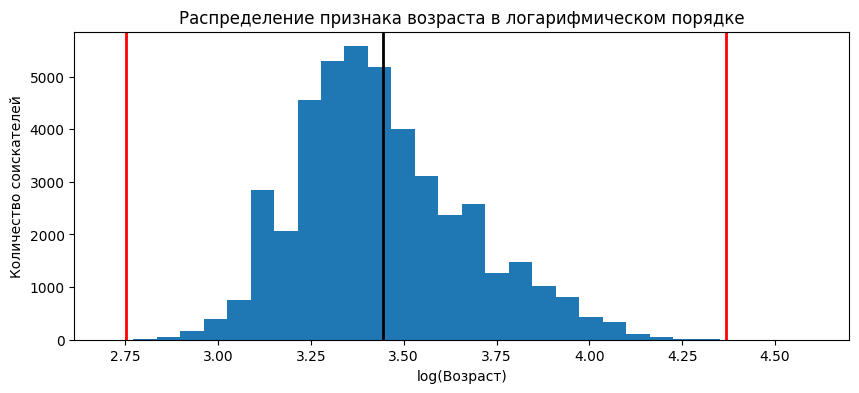

3


In [27]:
# логарифмируем данные по возрасту для построения графика
log_data = np.log(hh_data['Возраст'])

# математическое ожидание
mu = log_data.mean()
# стандартное отклонение
sigma = log_data.std()
# нижняя граница
lower_bound = mu - 3 * sigma
# верхняя граница (с учетом послабления)
upper_bound = mu + 4 * sigma

# график
plt.figure(figsize=(10,4))
plt.hist(log_data, bins=30)
plt.axvline(mu, color='k', lw=2)
plt.axvline(lower_bound, color='r', lw=2)
plt.axvline(upper_bound, color='r', lw=2)
plt.xlabel('log(Возраст)')
plt.ylabel('Количество соискателей')
plt.title('Распределение признака возраста в логарифмическом порядке')
plt.show()

# чистим данные
 # выбросы
outliers = hh_data[(log_data < lower_bound) | (log_data > upper_bound)]
# вычищенные от выбросов данные
cleaned = hh_data[(log_data >= lower_bound) & (log_data <= upper_bound)]

print(outliers.shape[0])

$\color{red}{\mathbf{Итог:}}$

График имеет правостороннюю ассиметрию.